In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.cluster import KMeans

In [2]:
df=pd.read_csv("h.csv")
df.head()

,Platform,Owner,Primary Usage,Country,Daily Time Spent (min),Verified Account,Date Joined
0,WhatsApp,Meta,Messaging,Switzerland,113.94,Yes,2019-03-03
1,WeChat,Tencent,Messaging and social media,Madagascar,49.63,Yes,2023-09-21
2,Snapchat,Snap Inc.,Multimedia messaging,Pitcairn Islands,29.01,Yes,2020-12-13
3,Instagram,Meta,Photo and video sharing,Timor-Leste,295.43,Yes,2019-04-21
4,Threads,Meta,Text-based social networking,Bermuda,71.78,No,2015-07-14


In [3]:
df =df.drop("Owner",axis=1)

In [4]:
df["Date Joined"] = pd.to_datetime(df["Date Joined"])

df["Account_Age"] = 2026 - df["Date Joined"].dt.year

df = df.drop("Date Joined", axis=1)

In [5]:
df

,Platform,Primary Usage,Country,Daily Time Spent (min),Verified Account,Account_Age
0,WhatsApp,Messaging,Switzerland,113.94,Yes,7
1,WeChat,Messaging and social media,Madagascar,49.63,Yes,3
2,Snapchat,Multimedia messaging,Pitcairn Islands,29.01,Yes,6
3,Instagram,Photo and video sharing,Timor-Leste,295.43,Yes,7
4,Threads,Text-based social networking,Bermuda,71.78,No,11
...,...,...,...,...,...,...
9995,Pinterest,Visual discovery and bookmarking,Morocco,249.12,No,2
9996,Reddit,Discussion forums and communities,Cape Verde,111.38,Yes,9
9997,Quora,Q&A knowledge sharing,Poland,87.88,No,8
9998,Quora,Q&A knowledge sharing,Lao People's Democratic Republic,205.69,Yes,7


In [6]:
features = df.columns

print(features)

Index(['Platform', 'Primary Usage', 'Country', 'Daily Time Spent (min)',
       'Verified Account', 'Account_Age'],
      dtype='object')


In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(list(numerical_cols))

['Daily Time Spent (min)']


In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

print(list(categorical_cols))

['Platform', 'Primary Usage', 'Country', 'Verified Account']


In [9]:

numerical_continuous = ["Daily Time Spent (min)"]
numerical_discrete = []

categorical_nominal = ["Platform", "Primary Usage", "Country"]
categorical_binary = ["Verified Account"]

print("\n Classification détaillée:")
print("Continues:", numerical_continuous)
print("Discrètes:", numerical_discrete)
print("Nominales:", categorical_nominal)
print("Binaires:", categorical_binary)


 Classification détaillée:
Continues: ['Daily Time Spent (min)']
Discrètes: []
Nominales: ['Platform', 'Primary Usage', 'Country']
Binaires: ['Verified Account']


In [10]:
imputer = SimpleImputer(strategy="most_frequent")
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [11]:
le = LabelEncoder()
for col in ["Platform", "Primary Usage", "Country", "Verified Account"]:
    df[col] = le.fit_transform(df[col])

In [12]:
df.isna().sum()

,0
Platform,0
Primary Usage,0
Country,0
Daily Time Spent (min),0
Verified Account,0
Account_Age,0


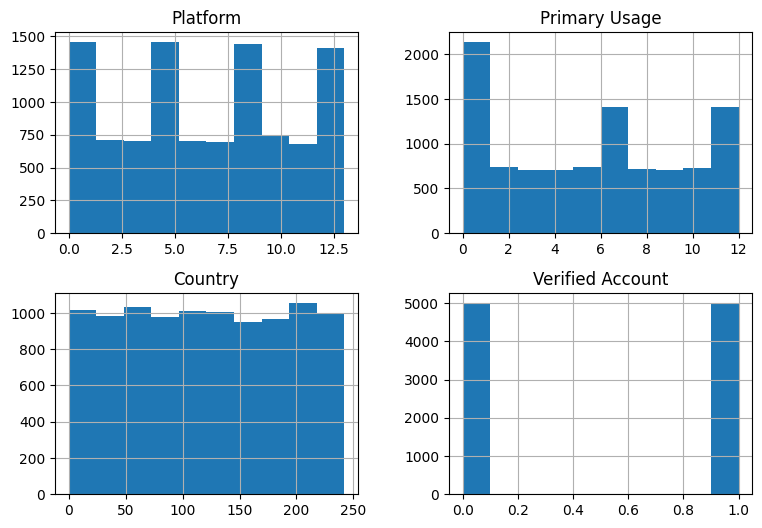

In [13]:
df.hist(figsize=(9,6))
plt.show()

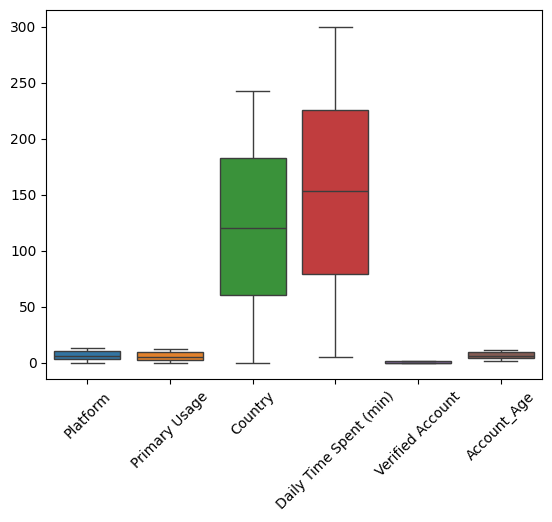

In [14]:
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

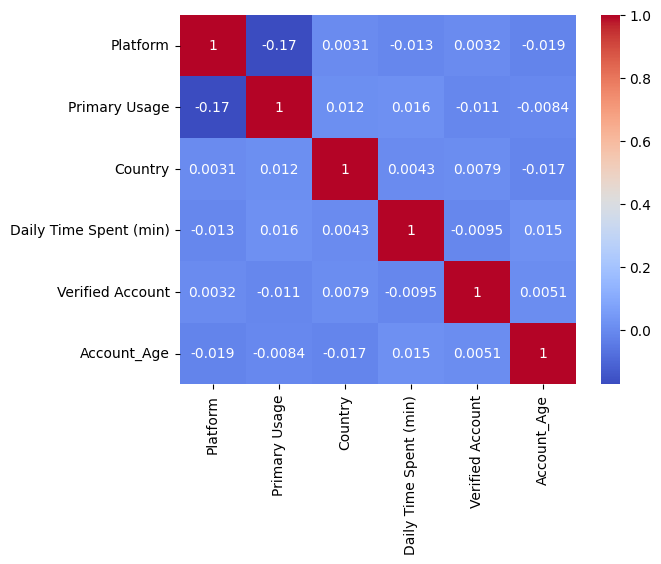

In [15]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

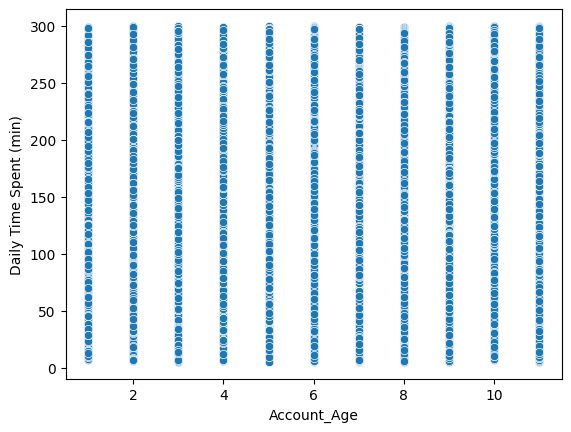

In [16]:
sns.scatterplot(x=df["Account_Age"], y=df["Daily Time Spent (min)"])
plt.show()

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

In [18]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]


X = scaler.fit_transform(df)

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

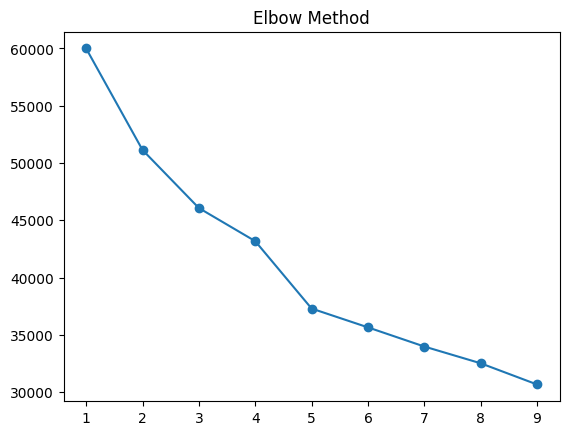

In [21]:
from sklearn.cluster import KMeans

inertia = []
K = range(1,10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

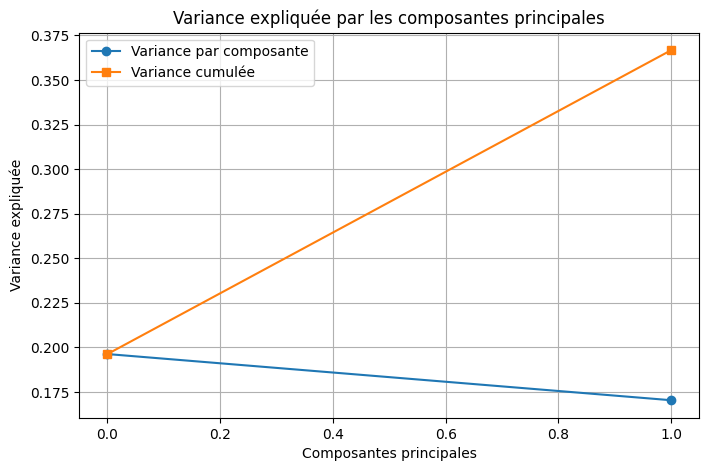

In [33]:



explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)


plt.figure(figsize=(8,5))

plt.plot(explained_variance, marker='o', label='Variance par composante')
plt.plot(cumulative_variance, marker='s', label='Variance cumulée')

plt.title("Variance expliquée par les composantes principales")
plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée")
plt.legend()
plt.grid()

plt.show()

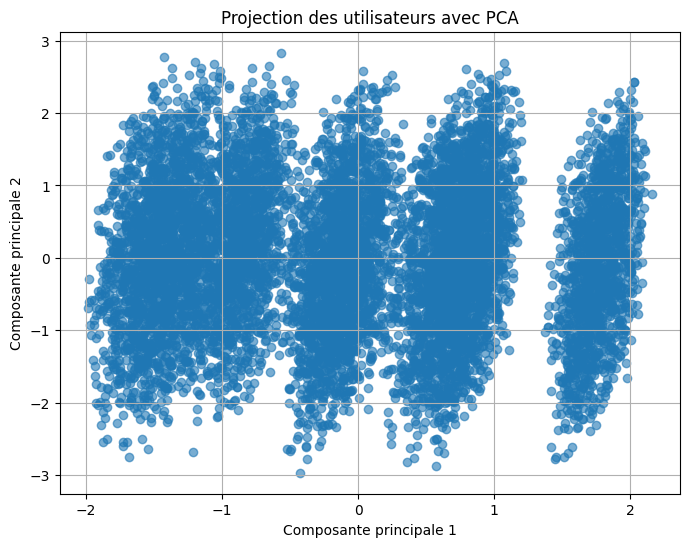

In [35]:










plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.6)

plt.title("Projection des utilisateurs avec PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.grid()
plt.show()

In [24]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)


In [25]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X)

In [26]:
gmm = GaussianMixture(n_components=3)
labels_gmm = gmm.fit_predict(X)

In [27]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X, quantile=0.2)
ms = MeanShift(bandwidth=bandwidth)
labels_ms = ms.fit_predict(X)

In [37]:


def evaluate(name, labels):
    if len(set(labels)) > 1:
        print(f"\n{name}")
        print("Silhouette:", silhouette_score(X, labels))
        print("Davies-Bouldin:", davies_bouldin_score(X, labels))
        print("Calinski-Harabasz:", calinski_harabasz_score(X, labels))

evaluate("KMeans", labels_kmeans)
evaluate("DBSCAN", labels_dbscan)
evaluate("Hierarchical", labels_hc)
evaluate("GMM", labels_gmm)
evaluate("MeanShift", labels_ms)


KMeans
Silhouette: 0.13957549996556137
Davies-Bouldin: 2.246157397436431
Calinski-Harabasz: 1511.6990687537177

DBSCAN
Silhouette: 0.1740924846811828
Davies-Bouldin: 2.1892758810952775
Calinski-Harabasz: 2000.3673441898973

Hierarchical
Silhouette: 0.15110364076502847
Davies-Bouldin: 2.0796766950283936
Calinski-Harabasz: 1538.6014397395425

GMM
Silhouette: 0.13810033415384187
Davies-Bouldin: 2.184435621653657
Calinski-Harabasz: 1493.7044176839038


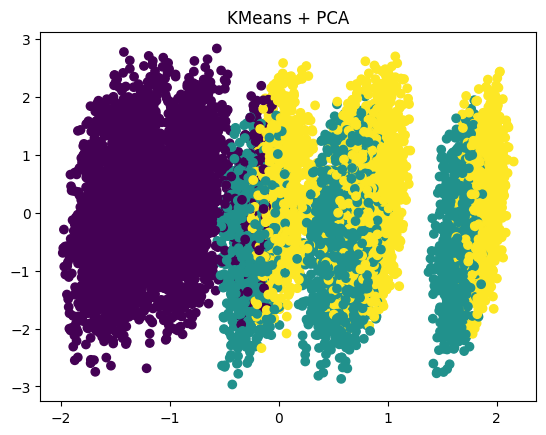

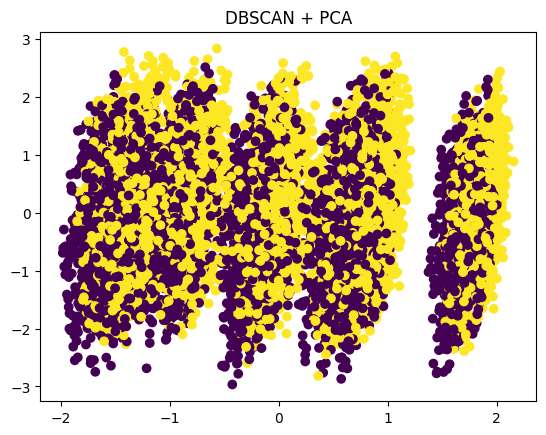

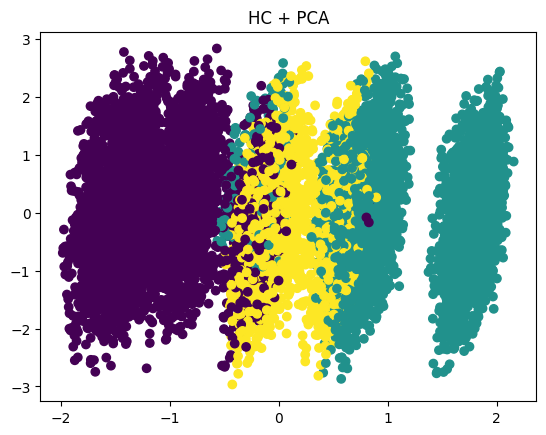

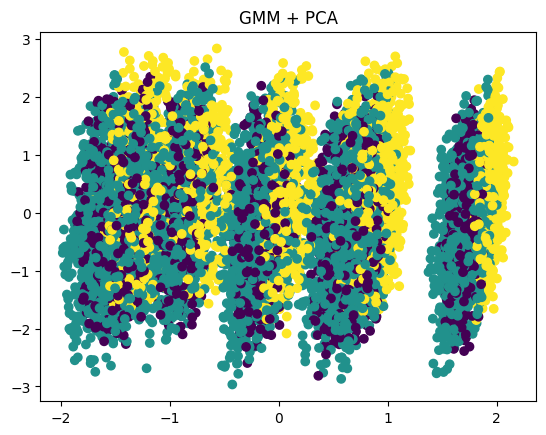

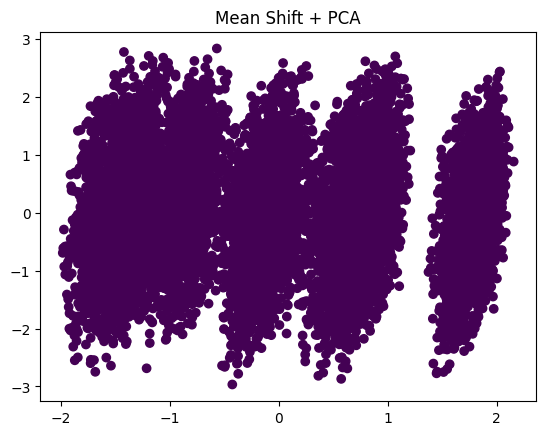

In [29]:
def plot_clusters(X_vis, labels, title):
    plt.scatter(X_vis[:,0], X_vis[:,1], c=labels)
    plt.title(title)
    plt.show()

plot_clusters(X_pca, labels_kmeans, "KMeans + PCA")
plot_clusters(X_pca, labels_dbscan, "DBSCAN + PCA")
plot_clusters(X_pca, labels_hc, "HC + PCA")
plot_clusters(X_pca, labels_gmm, "GMM + PCA")
plot_clusters(X_pca, labels_ms, "Mean Shift + PCA")


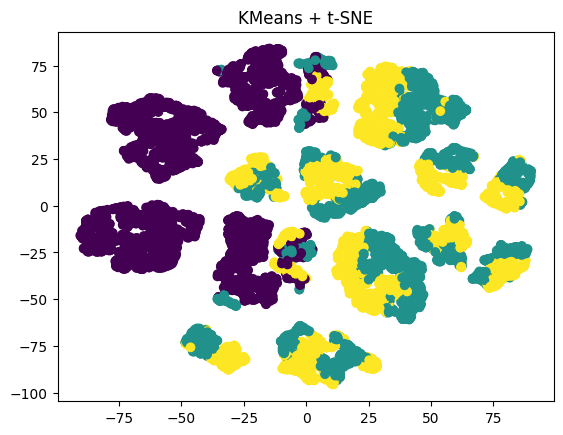

In [30]:
plot_clusters(X_tsne, labels_kmeans, "KMeans + t-SNE")

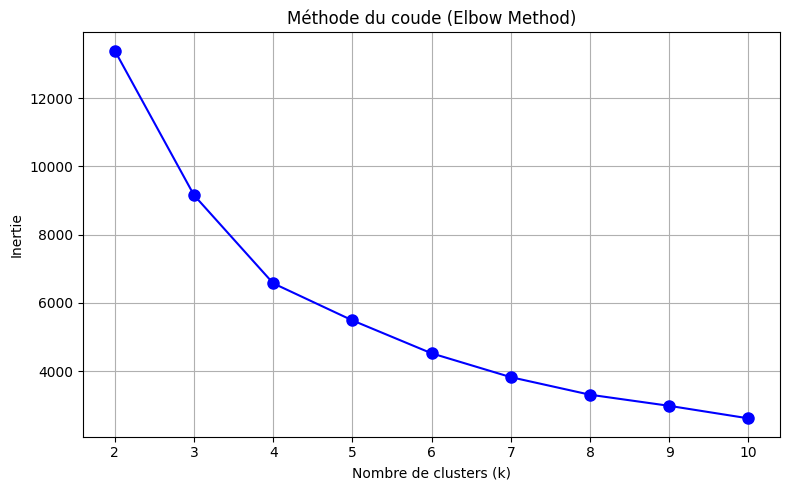

In [31]:


inertias = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude (Elbow Method)')
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()

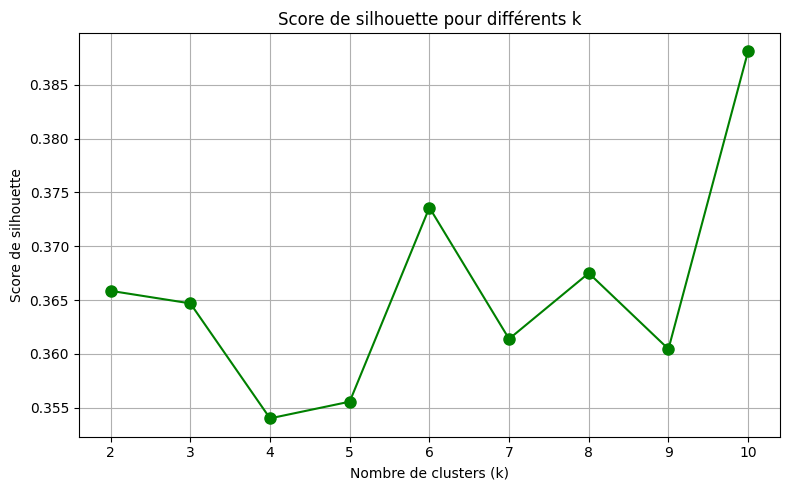

Meilleur k : 10 avec un score de 0.3881


In [38]:


silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, 'go-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette pour différents k')
plt.grid(True)
plt.tight_layout()
plt.savefig('fig5_silhouette_score.png', dpi=150)
plt.show()

best_k = K[silhouette_scores.index(max(silhouette_scores))]
print(f"Meilleur k : {best_k} avec un score de {max(silhouette_scores):.4f}")

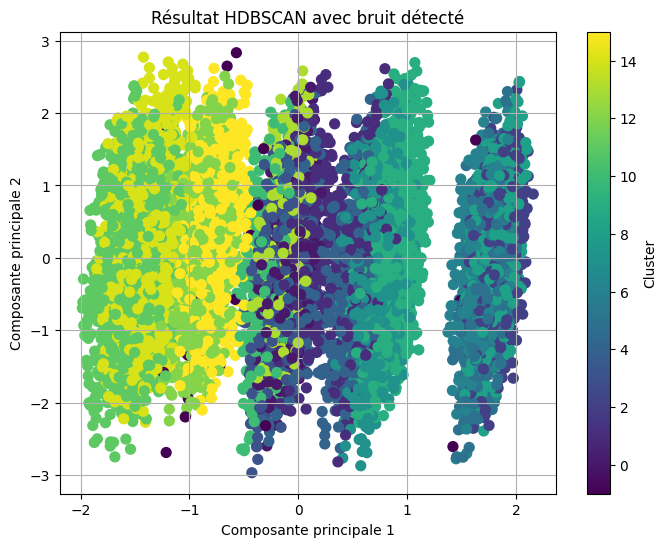

In [40]:

import hdbscan



hdb = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5
)

labels = hdb.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='viridis',
    s=50
)

plt.title("Résultat HDBSCAN avec bruit détecté")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.colorbar(label='Cluster')
plt.grid(True)

plt.show()